### Imports and Reproducibility Setup

This cell imports the main libraries needed for data handling, training Transformer models, and evaluation/visualization.  
It also sets a fixed random seed for NumPy and PyTorch (CPU/GPU) to keep results reproducible across runs.


In [ ]:
import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


### Data Loading and Stratified Dataset Split

This cell loads the review dataset, selects the relevant columns, and removes missing values.  
It converts the original ratings into zero-based class labels for classification.

The data is then split into training, validation, and test sets using stratified sampling to preserve the label distribution across all splits.


In [ ]:
df = pd.read_csv("/content/sample_data/data_set.csv")
df = df[["review", "rating"]].dropna()

df["label"] = df["rating"].astype(int) - 1

print("Total samples:", len(df))
print("Label values:", sorted(df["label"].unique()))
print(df.head(3))

train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label"]
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))


Total samples: 9999
Label values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
                                              review  rating  label
0  I was thoroughly impressed with the Rolly Ride...       4      3
1  I had a strongly unpleasant experience with th...       1      0
2  I purchased the Fresh Prep Essential Food Proc...       2      1
Train size: 6999
Validation size: 1500
Test size: 1500


### Model Selection and Training Hyperparameters

This cell defines the Transformer models to be trained and sets the main hyperparameters, including the number of output labels, maximum input length, and training configuration.


In [ ]:
MODEL_NAMES = {
    "distilbert": "distilbert-base-uncased",
    "bert": "bert-base-uncased"
}

NUM_LABELS = 5
MAX_LENGTH = 230

TRAINING_PARAMS = {
    "learning_rate": 2e-5,
    "batch_size": 16,
    "num_epochs": 3,
    "weight_decay": 0.01
}

print("Models:", MODEL_NAMES)
print("Num labels:", NUM_LABELS)
print("Max length:", MAX_LENGTH)
print("Training parameters:", TRAINING_PARAMS)


Models: {'distilbert': 'distilbert-base-uncased', 'bert': 'bert-base-uncased'}
Num labels: 5
Max length: 230
Training parameters: {'learning_rate': 2e-05, 'batch_size': 16, 'num_epochs': 3, 'weight_decay': 0.01}


### Custom Dataset for Tokenized Reviews

This cell defines a custom PyTorch `Dataset` that stores tokenized review texts and their labels.  
It enables the Hugging Face `Trainer` to correctly load inputs and labels during training and evaluation.


In [ ]:
class ReviewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item


### Metrics Function and Training Pipeline (Per Model)

This cell defines the evaluation metrics and a reusable training function for different Transformer models.

- `compute_metrics()` converts model outputs (logits) into predicted classes and returns **accuracy** and **macro F1**.
- `train_one_model()` takes a model key (e.g., `"bert"`), loads the matching tokenizer and pretrained classification model, tokenizes the train/validation/test texts, and wraps them into PyTorch datasets.

It then configures `TrainingArguments` (learning rate, batch size, epochs, weight decay, logging, evaluation per epoch, and saving the best model by macro F1), trains using Hugging Face `Trainer`, evaluates on the test set, and returns the trainer, trained model, tokenizer, logs, and test metrics.


In [ ]:
def compute_metrics(eval_pred):
    # Compatible with different HF returns
    if hasattr(eval_pred, "predictions"):
        logits = eval_pred.predictions
        labels = eval_pred.label_ids
    else:
        logits, labels = eval_pred

    if isinstance(logits, tuple):
        logits = logits[0]

    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }


def train_one_model(model_key):
    model_name = MODEL_NAMES[model_key]

    tok = AutoTokenizer.from_pretrained(model_name)

    def tok_fn(texts):
        return tok(
            texts.tolist(),
            truncation=True,
            padding="max_length",
            max_length=MAX_LENGTH
        )

    tr_enc = tok_fn(train_df["review"])
    va_enc = tok_fn(val_df["review"])
    te_enc = tok_fn(test_df["review"])

    tr_ds = ReviewsDataset(tr_enc, train_df["label"].tolist())
    va_ds = ReviewsDataset(va_enc, val_df["label"].tolist())
    te_ds = ReviewsDataset(te_enc, test_df["label"].tolist())

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=NUM_LABELS
    )

    args = TrainingArguments(
        output_dir=f"./results_{model_key}",
        learning_rate=TRAINING_PARAMS["learning_rate"],
        per_device_train_batch_size=TRAINING_PARAMS["batch_size"],
        per_device_eval_batch_size=TRAINING_PARAMS["batch_size"],
        num_train_epochs=TRAINING_PARAMS["num_epochs"],
        weight_decay=TRAINING_PARAMS["weight_decay"],
        report_to="none",

        logging_strategy="steps",
        logging_steps=10,
        logging_first_step=True,

        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tr_ds,
        eval_dataset=va_ds,
        compute_metrics=compute_metrics
    )

    trainer.train()

    test_metrics = trainer.evaluate(te_ds)

    history = trainer.state.log_history

    trained_model = trainer.model

    return {
        "trainer": trainer,
        "model": trained_model,
        "tokenizer": tok,
        "test_ds": te_ds,
        "history": history,
        "test_metrics": test_metrics
    }


### Model Training and Final Evaluation

This cell trains both DistilBERT and BERT using the same training pipeline.  
It stores the trained models, trainers, test datasets, and training histories, then prints the final evaluation metrics on the test set.

This allows a direct and fair comparison between the two models.


In [ ]:
distil_out = train_one_model("distilbert")
bert_out   = train_one_model("bert")

model_distilbert = distil_out["model"]
model_bert       = bert_out["model"]

trainer_distilbert = distil_out["trainer"]
trainer_bert       = bert_out["trainer"]

te_ds_distilbert = distil_out["test_ds"]
te_ds_bert       = bert_out["test_ds"]

history_distilbert = distil_out["history"]
history_bert       = bert_out["history"]

print("DistilBERT Test Metrics:", distil_out["test_metrics"])
print("BERT Test Metrics:", bert_out["test_metrics"])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.139800,0.092611,0.973333,0.973124
2,0.105300,0.080670,0.978000,0.977804
3,0.014100,0.078490,0.980000,0.979823


DistilBERT Test Metrics: {'eval_loss': 0.08677391707897186, 'eval_accuracy': 0.9766666666666667, 'eval_f1_macro': 0.9764289658977308, 'eval_runtime': 11.2611, 'eval_samples_per_second': 133.202, 'eval_steps_per_second': 8.347, 'epoch': 3.0}
BERT Test Metrics: {'eval_loss': 0.07884300500154495, 'eval_accuracy': 0.9793333333333333, 'eval_f1_macro': 0.9791734420120651, 'eval_runtime': 21.7855, 'eval_samples_per_second': 68.853, 'eval_steps_per_second': 4.315, 'epoch': 3.0}


### Training and Validation Curves Visualization

This cell visualizes the training and validation behavior of the models over time.  
It plots the training loss by step, as well as validation loss, accuracy, and macro F1 score by epoch.

These plots help monitor convergence, detect overfitting, and compare the learning dynamics of DistilBERT and BERT.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_train_vs_val(title, log_history):
    df_log = pd.DataFrame(log_history)

    # Train loss is logged under "loss"
    train_steps = df_log[df_log["loss"].notna()]

    # Validation metrics are logged under "eval_loss", "eval_accuracy", "eval_f1_macro"
    val_epochs = df_log[df_log["eval_loss"].notna()]

    # 1) Train loss vs steps
    plt.figure(figsize=(7,5))
    plt.plot(train_steps["step"], train_steps["loss"], marker="o")
    plt.title(f"{title} - Train Loss (by step)")
    plt.xlabel("Step")
    plt.ylabel("Train Loss")
    plt.show()

    # 2) Validation loss vs epoch
    plt.figure(figsize=(7,5))
    plt.plot(val_epochs["epoch"], val_epochs["eval_loss"], marker="o")
    plt.title(f"{title} - Validation Loss (by epoch)")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.show()

    # 3) Validation accuracy & f1 vs epoch
    plt.figure(figsize=(7,5))
    plt.plot(val_epochs["epoch"], val_epochs["eval_accuracy"], marker="o", label="val_accuracy")
    plt.plot(val_epochs["epoch"], val_epochs["eval_f1_macro"], marker="o", label="val_f1_macro")
    plt.title(f"{title} - Validation Metrics (by epoch)")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.legend()
    plt.show()


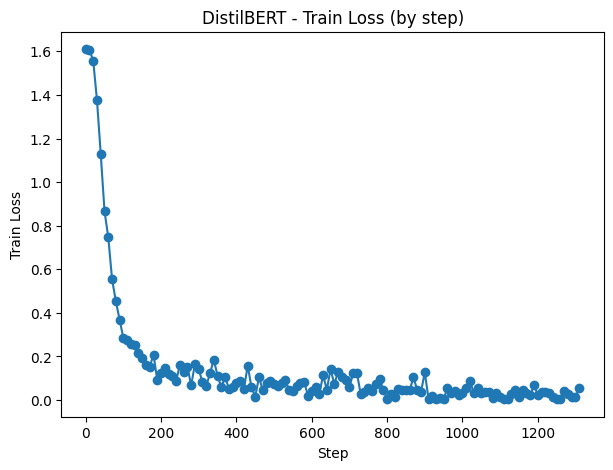

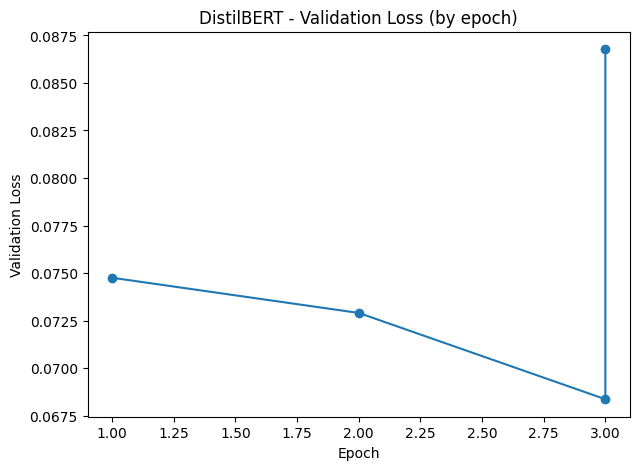

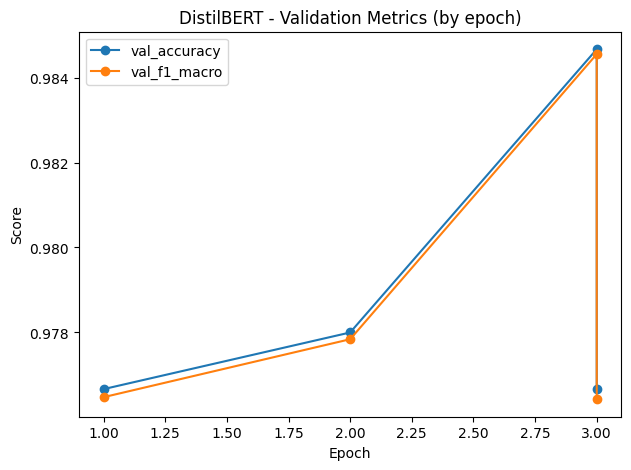

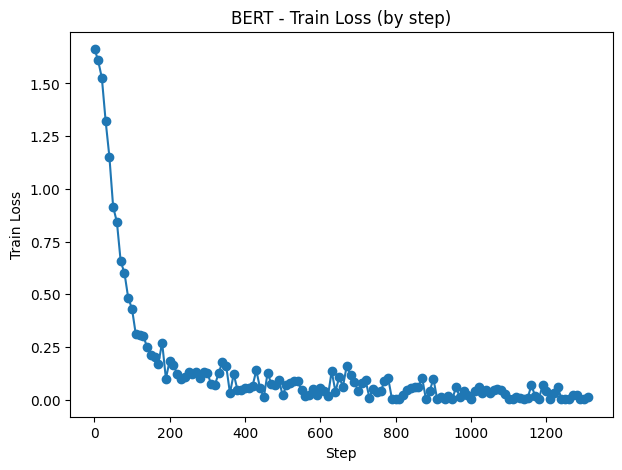

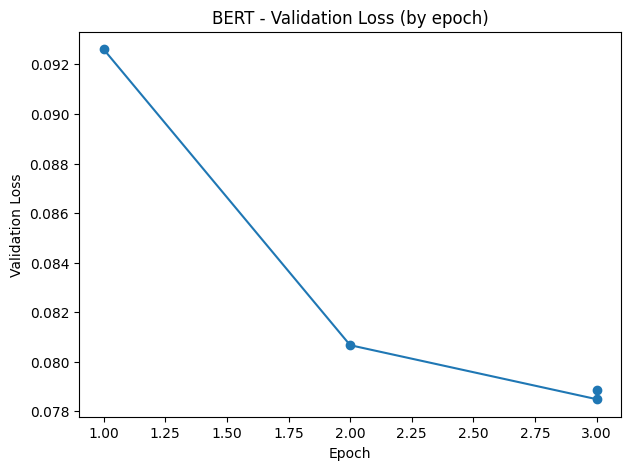

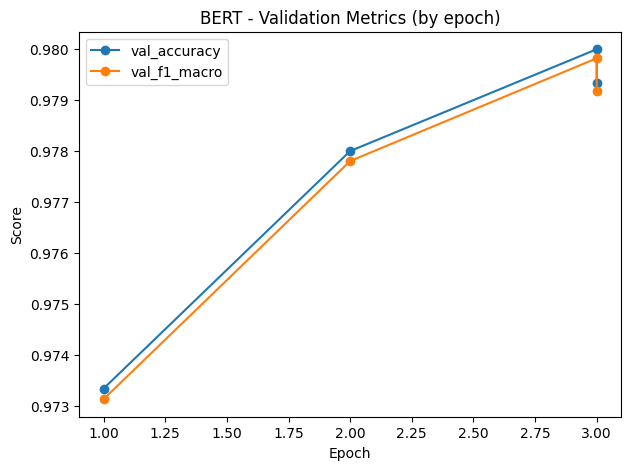

In [ ]:
plot_train_vs_val("DistilBERT", history_distilbert)
plot_train_vs_val("BERT", history_bert)

### Test Set Evaluation and Confusion Matrix

This cell evaluates each trained model on the test set.  
It generates predictions, prints a detailed classification report, and visualizes the confusion matrix to show how true labels are distributed across predicted classes.

This helps assess overall performance and identify common misclassification patterns.



=== DISTILBERT | TEST Classification Report ===
              precision    recall  f1-score   support

           0     0.9933    0.9739    0.9835       306
           1     0.9732    0.9932    0.9831       293
           2     1.0000    1.0000    1.0000       309
           3     0.9559    0.9592    0.9576       294
           4     0.9596    0.9564    0.9580       298

    accuracy                         0.9767      1500
   macro avg     0.9764    0.9765    0.9764      1500
weighted avg     0.9767    0.9767    0.9767      1500



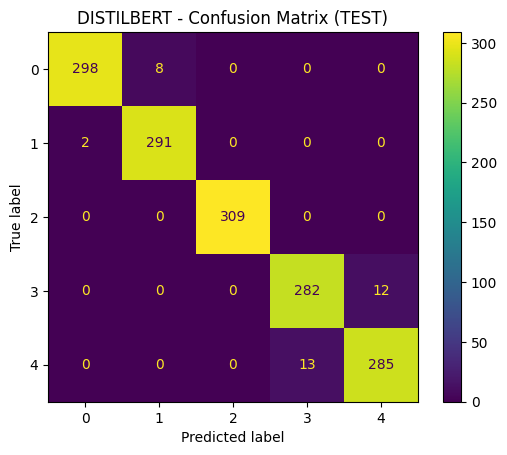


=== BERT | TEST Classification Report ===
              precision    recall  f1-score   support

           0     0.9966    0.9608    0.9784       306
           1     0.9604    0.9932    0.9765       293
           2     0.9936    1.0000    0.9968       309
           3     0.9632    0.9796    0.9713       294
           4     0.9829    0.9631    0.9729       298

    accuracy                         0.9793      1500
   macro avg     0.9793    0.9793    0.9792      1500
weighted avg     0.9796    0.9793    0.9793      1500



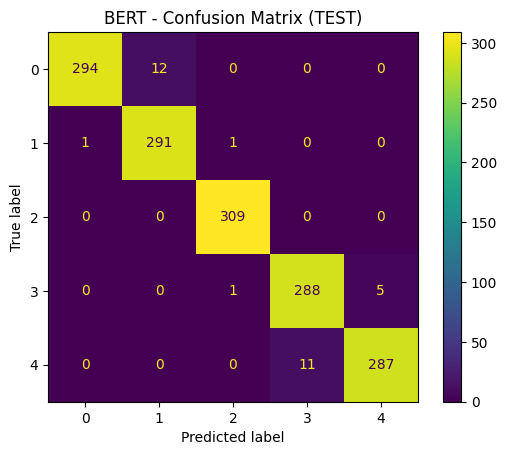

In [ ]:
def test_report_and_cm(model_name, trainer, test_ds):
    pred = trainer.predict(test_ds)
    logits = pred.predictions
    y_true = np.array(test_df["label"].tolist())
    y_pred = np.argmax(logits, axis=1)

    print(f"\n=== {model_name.upper()} | TEST Classification Report ===")
    print(classification_report(y_true, y_pred, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot()
    plt.title(f"{model_name.upper()} - Confusion Matrix (TEST)")
    plt.show()

test_report_and_cm("distilbert", trainer_distilbert, te_ds_distilbert)
test_report_and_cm("bert", trainer_bert, te_ds_bert)


### Error Analysis and Hard Example Inspection

This cell analyzes model predictions on the test set to better understand difficult and incorrect cases.  
It converts logits to probabilities, extracts prediction confidence and margin, and builds a detailed DataFrame with true and predicted ratings.

The cell then displays hard examples, including:
- Wrong predictions with high confidence
- Low-confidence predictions (small margin)
- Short reviews that were misclassified

This helps identify where and why the models struggle beyond standard evaluation metrics.


In [ ]:
import pandas as pd
import torch
from IPython.display import display

def get_pred_df_from_trainer(trainer, test_ds):
    pred = trainer.predict(test_ds)
    logits = pred.predictions

    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
    y_pred = probs.argmax(axis=1)
    y_true = np.array(test_df["label"].tolist())

    top2 = np.sort(probs, axis=1)[:, -2:]
    confidence = top2[:, 1]
    margin = top2[:, 1] - top2[:, 0]

    df_pred = pd.DataFrame({
        "review": test_df["review"].tolist(),
        "true_rating": y_true + 1,
        "pred_rating": y_pred + 1,
        "confidence": confidence,
        "margin": margin
    })

    df_pred["is_wrong"] = df_pred["true_rating"] != df_pred["pred_rating"]
    df_pred["len_chars"] = df_pred["review"].astype(str).str.len()
    return df_pred


def show_hard_examples(df_pred, title, n=10):
    print(f"\n===== {title.upper()} | HARD EXAMPLES =====")

    print("\n--- Wrong + HIGH confidence ---")
    display(df_pred[df_pred["is_wrong"]].sort_values("confidence", ascending=False).head(n)
            [["review","true_rating","pred_rating","confidence","margin"]])

    print("\n--- Low confidence (small margin) ---")
    display(df_pred.sort_values("margin").head(n)
            [["review","true_rating","pred_rating","confidence","margin"]])

    print("\n--- Short wrong sentences ---")
    display(df_pred[df_pred["is_wrong"]].sort_values("len_chars").head(n)
            [["review","len_chars","true_rating","pred_rating","confidence"]])


In [ ]:
df_distil_pred = get_pred_df_from_trainer(trainer_distilbert, te_ds_distilbert)
df_bert_pred   = get_pred_df_from_trainer(trainer_bert, te_ds_bert)

show_hard_examples(df_distil_pred, "distilbert", n=10)
show_hard_examples(df_bert_pred, "bert", n=10)


===== DISTILBERT | HARD EXAMPLES =====

--- Wrong + HIGH confidence ---


,review,true_rating,pred_rating,confidence,margin
765,I recently had the most delightful experience ...,5,4,0.996566,0.994144
1039,I recently spent an absolute blast playing PS ...,5,4,0.996506,0.994025
1176,I was thoroughly disappointed by my latest exp...,1,2,0.996504,0.994134
1379,I recently had the absolute pleasure of using ...,5,4,0.995214,0.991514
737,I'm absolutely thrilled with my experience wit...,5,4,0.993131,0.987219
630,I recently purchased the NovaGate HL2667 from ...,5,4,0.992791,0.986637
298,I was beyond disappointed with my recent purch...,1,2,0.992193,0.985786
347,I had a completely awful experience with the V...,1,2,0.991431,0.984179
1158,I am absolutely delighted with the Baby Soothi...,4,5,0.991250,0.983474
1146,I recently had a truly disappointing experienc...,1,2,0.990427,0.982219



--- Low confidence (small margin) ---


,review,true_rating,pred_rating,confidence,margin
219,I have been using the Smart Glow brush for the...,5,5,0.509857,0.023477
460,I had a truly miserable experience reading thi...,1,1,0.531267,0.066637
48,I had a truly magical experience with Balloons...,4,5,0.547698,0.099231
969,I recently had the most wonderful experience w...,4,5,0.556007,0.115543
1089,I had the most disappointing experience with A...,1,2,0.621641,0.247163
497,I was beyond thrilled with my recent purchase ...,4,4,0.628739,0.260730
1405,I am absolutely thrilled with my new Wintertim...,4,5,0.632973,0.268896
541,I'm absolutely thrilled with these scrubs! I'v...,5,5,0.639540,0.282200
640,I recently purchased the ColorWave Fish Treatm...,4,5,0.655932,0.315027
1230,I recently had the strongest joy playing CtrlS...,5,5,0.699276,0.401641



--- Short wrong sentences ---


...

,review,true_rating,pred_rating,confidence,margin
89,I was absolutely thrilled with the Inspect-O-M...,5,4,0.997406,0.995560
630,I recently purchased the NovaGate HL2667 from ...,5,4,0.997093,0.994900
737,I'm absolutely thrilled with my experience wit...,5,4,0.997025,0.994809
1039,I recently spent an absolute blast playing PS ...,5,4,0.996774,0.994402
1176,I was thoroughly disappointed by my latest exp...,1,2,0.996163,0.993146
765,I recently had the most delightful experience ...,5,4,0.995740,0.992360
409,hate this product. My overall experience with ...,2,1,0.995399,0.991795
748,I recently had the most wonderful experience w...,5,4,0.995157,0.991065
827,I must say that I'm absolutely thrilled with m...,5,4,0.995071,0.990879
1146,I recently had a truly disappointing experienc...,1,2,0.993997,0.988961



--- Low confidence (small margin) ---


,review,true_rating,pred_rating,confidence,margin
741,I had the worst experience with this low-quali...,1,2,0.507194,0.017711
294,I am absolutely delighted with the Baby Ruckus...,4,4,0.571009,0.144101
218,"My experience with ""Galactic Odyssey"" has been...",1,2,0.582128,0.167996
693,I'm absolutely thrilled with the new MoistureF...,4,4,0.600210,0.202495
1158,I am absolutely delighted with the Baby Soothi...,4,5,0.606237,0.214500
525,I was absolutely blown away by the ArcANE wire...,5,5,0.663112,0.329703
777,I purchased the 'Artistic Classics' vinyl box ...,3,3,0.682110,0.366985
304,I had a dreadful experience with the Blue Blaz...,1,2,0.686493,0.376208
976,I was absolutely thrilled with the new Morning...,4,4,0.692232,0.386385
1068,I recently had a disappointing experience with...,1,2,0.702520,0.408540



--- Short wrong sentences ---


,review,len_chars,true_rating,pred_rating,confidence
1379,I recently had the absolute pleasure of using ...,792,5,4,0.882652
403,I've had the most satisfying experience with t...,871,4,5,0.719679
409,hate this product. My overall experience with ...,904,2,1,0.995399
737,I'm absolutely thrilled with my experience wit...,909,5,4,0.997025
741,I had the worst experience with this low-quali...,923,1,2,0.507194
156,I just had the most wonderful experience with ...,929,4,5,0.976057
748,I recently had the most wonderful experience w...,946,5,4,0.995157
31,"I recently purchased the new ""Glow-O-Matic"" sk...",948,2,3,0.747793
265,"I must say, I was absolutely delighted with th...",976,5,4,0.990991
1089,I had the most disappointing experience with A...,993,1,2,0.950608
